In [1]:
from pathlib import Path
import subprocess

REPO_URL = "https://github.com/seoultechpse/fenicsx-colab.git"
ROOT = Path("/content")
REPO_DIR = ROOT / "fenicsx-colab"

subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

USE_COMPLEX = False  # <--- Set True ONLY if you need complex PETSc
USE_CLEAN = False    # <--- Set True to remove existing environment

opts_str = " ".join(
  [o for c, o in [(USE_COMPLEX, "--complex"), (USE_CLEAN, "--clean")] if c]
)

get_ipython().run_line_magic("run", f"{REPO_DIR / 'setup_fenicsx.py'} {opts_str}")

🔧 FEniCSx Setup Configuration
PETSc type      : real
Clean install   : False

⚠️  Google Drive not mounted — using local cache (/content)

🔧 Installing FEniCSx environment...

🔍 Verifying PETSc type...
✅ Installed: Real PETSc (float64)

✨ Loading FEniCSx Jupyter magic... %%fenicsx registered

✅ FEniCSx setup complete!

Next steps:
  1. Run %%fenicsx --info to verify installation
  2. Use %%fenicsx in cells to run FEniCSx code
  3. Use -np N for parallel execution (e.g., %%fenicsx -np 4)

📌 Note: Real PETSc is installed
   - Recommended for most FEM problems
   - For complex problems, reinstall with --complex


---

In [2]:
%%fenicsx

"""
Efficient Usage of the Unified Form Language
FEniCS Workshop - DOLFINx Deep Dive
"""

# ============================================================================
# IMPORT LIBRARIES
# ============================================================================
from mpi4py import MPI
import numpy as np
import matplotlib.pyplot as plt
import time

import dolfinx
import dolfinx.fem.petsc
import ufl
from dolfinx.io import VTXWriter
import dolfinx.plot

print(f"DOLFINx version: {dolfinx.__version__}")
print(f"UFL version: {ufl.__version__}")

# ============================================================================
# MESH AND FUNCTION SPACE
# ============================================================================
# Create unit square mesh
mesh = dolfinx.mesh.create_unit_square(MPI.COMM_WORLD, 30, 30)
V = dolfinx.fem.functionspace(mesh, ("Lagrange", 1))

print(f"Number of degrees of freedom: {V.dofmap.index_map.size_global}")
print(f"Mesh has {mesh.topology.index_map(2).size_global} cells")

# ============================================================================
# TIME-DEPENDENT CONSTANTS
# ============================================================================
# Define diffusion coefficient function
def k_func(t):
    """Time-dependent diffusion coefficient"""
    return 0.1 if t < 0.5 else 0.05

# Define Constants
dt = dolfinx.fem.Constant(mesh, 0.01)
k = dolfinx.fem.Constant(mesh, k_func(0.0))  # Initialize with correct value at t=0
t = dolfinx.fem.Constant(mesh, 0.0)

print(f"Time step dt: {dt.value}")
print(f"Initial diffusion coefficient k(0): {k.value}")
print(f"Initial time t: {t.value}")

# ============================================================================
# CONDITIONAL EXPRESSIONS
# ============================================================================
# Get spatial coordinates
x, y = ufl.SpatialCoordinate(mesh)

# Define conditional source term
condition = ufl.lt(x, 0.5)   # x < 0.5
true_statement = 0.4 * y     # Left half: source proportional to y
false_statement = 0.5 * t    # Right half: source proportional to time

f = ufl.conditional(condition, true_statement, false_statement)

print("Source term f(x,y,t) defined with ufl.conditional")
print("  Left half (x < 0.5): f = 0.4 * y")
print("  Right half (x >= 0.5): f = 0.5 * t")

# ============================================================================
# VARIATIONAL FORMULATION
# ============================================================================
# Define trial and test functions
u = ufl.TrialFunction(V)
v = ufl.TestFunction(V)

# Previous time step solution
u_n = dolfinx.fem.Function(V)

# Time derivative using backward Euler
dudt = (u - u_n) / dt

# Define measure
dx = ufl.Measure("dx", domain=mesh)

# Variational form F(u, v)
F = dudt * v * dx + k * ufl.inner(ufl.grad(u), ufl.grad(v)) * dx - f * v * dx

print("Variational form F(u, v) defined")
print("All time-varying terms use Constants or conditionals")

# ============================================================================
# AUTOMATIC FORM EXTRACTION
# ============================================================================
# Extract bilinear form a(u,v) and linear form L(v)
a, L = ufl.system(F)

print("Forms extracted:")
print("  a(u,v): bilinear form (left-hand side)")
print("  L(v):   linear form (right-hand side)")

# ============================================================================
# EXPLICIT CODE GENERATION AND COMPILATION
# ============================================================================
print("Compiling forms (this may take a few seconds)...")
start_time = time.time()

a_compiled = dolfinx.fem.form(a)
L_compiled = dolfinx.fem.form(L)

compile_time = time.time() - start_time
print(f"Forms compiled in {compile_time:.2f} seconds")
print("These compiled forms will be reused for all time steps!")

# ============================================================================
# INITIAL CONDITIONS
# ============================================================================
def u_init(x, sigma=0.1, mu=0.3):
    """
    Gaussian initial condition.

    Parameters:
    -----------
    x : numpy array of shape (3, num_points)
        Spatial coordinates
    sigma : float
        Standard deviation
    mu : float
        Mean (center of Gaussian)
    """
    return (
        1.0 / (2 * np.pi * sigma)
        * np.exp(-0.5 * ((x[0] - mu) / sigma) ** 2)
        * np.exp(-0.5 * ((x[1] - mu) / sigma) ** 2)
    )

# Interpolate initial condition
u_n.interpolate(u_init)

print(f"Initial condition set")
print(f"  Max value: {u_n.x.array.max():.6f}")
print(f"  Min value: {u_n.x.array.min():.6f}")

# ============================================================================
# VISUALIZE INITIAL CONDITION
# ============================================================================
# Create a grid for visualization
topology, cell_types, geometry = dolfinx.plot.vtk_mesh(V)

# Create a structured grid for plotting
n_plot = 50
x_plot = np.linspace(0, 1, n_plot)
y_plot = np.linspace(0, 1, n_plot)
X, Y = np.meshgrid(x_plot, y_plot)
points = np.zeros((3, n_plot * n_plot))
points[0] = X.flatten()
points[1] = Y.flatten()

# Evaluate initial condition on grid
u_grid = u_init(points).reshape((n_plot, n_plot))

# Store min/max for consistent colorbar later
u_min_global = 0.0
u_max_global = float(u_n.x.array.max())

# Plot
plt.figure(figsize=(8, 6))
cf = plt.contourf(X, Y, u_grid, levels=20, cmap='hot',
             vmin=u_min_global, vmax=u_max_global)
cbar = plt.colorbar(cf)
cbar.set_label('u(x,y,t=0)')
cbar.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5])

plt.xlabel('x')
plt.ylabel('y')
plt.title('Initial Condition: Gaussian Distribution')

plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)
plt.margins(0)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout(pad=0)
plt.savefig('initial_condition.png', dpi=150, bbox_inches='tight')
print("Initial condition plot saved to: initial_condition.png")
plt.close()  # Close instead of show for batch processing

# ============================================================================
# LINEAR SOLVER SETUP
# ============================================================================
# Solution function
uh = dolfinx.fem.Function(V)

# PETSc solver options (direct solver using MUMPS)
petsc_options = {
    "ksp_type": "preonly",
    "pc_type": "lu",
    "pc_factor_mat_solver_type": "mumps",
}

# Create linear problem
problem = dolfinx.fem.petsc.LinearProblem(
    a_compiled,
    L_compiled,
    u=uh,
    bcs=[],  # No Dirichlet BCs (Neumann everywhere)
    petsc_options=petsc_options,
    petsc_options_prefix="form_compilation_"
)

print("Linear solver configured")
print("Using direct solver (LU factorization with MUMPS)")

# ============================================================================
# TIME STEPPING LOOP
# ============================================================================
# Time stepping parameters
T = 1.0  # Final time
num_steps = int(T / dt.value)

# Reset to ensure correct initial values
t.value = 0.0
k.value = k_func(0.0)
dt.value = 0.01

# Storage for monitoring (convert to float to avoid numpy array reference issues)
times = [0.0]
max_values = [float(u_n.x.array.max())]
k_values = [float(k.value)]

print(f"\nInitial values before time loop:")
print(f"  t = {t.value}")
print(f"  k = {k.value}")
print(f"  dt = {dt.value}")
print(f"  max(u_n) = {u_n.x.array.max():.6f}")

# Time stepping loop
print(f"Starting time integration ({num_steps} steps)...")
print("Saving time series for ParaView animation...")
start_time = time.time()

# Create VTX writer for time series animation
vtx_file = VTXWriter(MPI.COMM_WORLD, "solution_time_series.bp", [uh], engine="BP4")
vtx_file.write(0.0)  # Write initial condition

step = 0
save_interval = 5  # Save every 5 steps for animation

while t.value < T:
    # Update time
    t.value += dt.value

    # Update diffusion coefficient
    k.value = k_func(t.value)

    # Solve the linear system (reassembles with new constant values)
    problem.solve()

    # Update previous solution
    u_n.x.array[:] = uh.x.array

    # Store data for monitoring
    step += 1
    if step % 10 == 0:
        times.append(float(t.value))  # Convert to float to avoid reference issue
        max_values.append(float(uh.x.array.max()))  # Convert to float
        k_values.append(float(k.value))  # Convert to float to avoid reference issue

    # Save to VTK for ParaView animation
    if step % save_interval == 0:
        vtx_file.write(float(t.value))

    # Progress output
    if step % 20 == 0:
        print(f"  Step {step}/{num_steps}, t = {t.value:.3f}, k = {k.value}, max(u) = {uh.x.array.max():.6f}")

# Close VTX writer
vtx_file.close()

solve_time = time.time() - start_time
print(f"\nTime integration completed in {solve_time:.2f} seconds")
print(f"Average time per step: {solve_time/num_steps*1000:.2f} ms")
print(f"Final time: t = {t.value:.3f}")
print(f"Final max value: {uh.x.array.max():.6f}")
print(f"Saved {num_steps // save_interval + 1} time steps for ParaView animation")

# ============================================================================
# MONITOR SOLUTION EVOLUTION
# ============================================================================
# Plot maximum value over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot max value
ax1.plot(times, max_values, 'bs')
ax1.set_xlabel('Time', fontsize=12)
ax1.set_ylabel('max(u)', fontsize=12)
ax1.set_title('Evolution of Maximum Value', fontsize=14)
ax1.grid(True, alpha=0.3)

# Plot diffusion coefficient
ax2.plot(times, k_values, 'rs')
ax2.set_xlabel('Time', fontsize=12)
ax2.set_ylabel('k(t)', fontsize=12)
ax2.set_title('Time-Dependent Diffusion Coefficient', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0.04, 0.11])

plt.tight_layout()
plt.savefig('solution_evolution.png', dpi=150, bbox_inches='tight')
print("Solution evolution plot saved to: solution_evolution.png")
plt.close()

# ============================================================================
# VISUALIZE INITIAL vs FINAL SOLUTION (Side-by-Side)
# ============================================================================
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm

# ==================================================
# USER FLAG: toggle color scaling
# ==================================================
USE_LOG_SCALE = False   # ← False = linear, True = log

# ==================================================
# Safety parameters
# ==================================================
eps = 1e-6  # for log(0) protection

# ==================================================
# Data preparation
# ==================================================
u0 = u_grid.copy()
uT = uh.x.array.copy()

if USE_LOG_SCALE:
    u0 = np.maximum(u0, eps)
    uT = np.maximum(uT, eps)

# ==================================================
# Color scaling setup
# ==================================================
if USE_LOG_SCALE:
    umin = max(u_min_global, eps)
    umax = u_max_global

    levels = np.logspace(
        np.log10(umin),
        np.log10(umax),
        21
    )
    norm = LogNorm(vmin=umin, vmax=umax)
    scale_label = 'log scale'
else:
    umin = u_min_global
    umax = u_max_global

    levels = np.linspace(umin, umax, 21)
    norm = None
    scale_label = 'linear scale'

# --------------------------------------------------
# Figure & layout (GridSpec)
# --------------------------------------------------
fig = plt.figure(figsize=(16, 6))

gs = gridspec.GridSpec(
    nrows=1,
    ncols=3,
    width_ratios=[1, 1, 0.045],  # last column = colorbar
    wspace=0.15
)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
cax = fig.add_subplot(gs[0, 2])

# --------------------------------------------------
# Left panel: Initial condition
# --------------------------------------------------
im1 = ax1.contourf(
    X, Y, u0,
    levels=levels,
    cmap='hot',
    norm=norm,
    vmin=None if USE_LOG_SCALE else umin,
    vmax=None if USE_LOG_SCALE else umax
)

ax1.set_title(
    f'Initial Condition (t = 0)\nmax(u) = {u0.max():.3e}',
    fontsize=14,
    fontweight='bold'
)
ax1.set_xlabel('x', fontsize=12)
ax1.set_ylabel('y', fontsize=12)
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# --------------------------------------------------
# Right panel: Final solution
# --------------------------------------------------
im2 = ax2.tricontourf(
    geometry[:, 0],
    geometry[:, 1],
    uT,
    levels=levels,
    cmap='hot',
    norm=norm,
    vmin=None if USE_LOG_SCALE else umin,
    vmax=None if USE_LOG_SCALE else umax
)

ax2.set_title(
    f'Final Solution (t = {T})\nmax(u) = {uh.x.array.max():.3f}',
    fontsize=14,
    fontweight='bold'
)
ax2.set_xlabel('x', fontsize=12)
ax2.set_ylabel('y', fontsize=12)
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# --------------------------------------------------
# Shared colorbar (aligned with both plots)
# --------------------------------------------------
cbar = fig.colorbar(im2, cax=cax)
cbar.set_label(
    f'Temperature u(x,y) [{scale_label}]',
    fontsize=12,
    rotation=90,
    labelpad=12
)

if USE_LOG_SCALE:
    log_ticks = [1e-4, 1e-3, 1e-2, 1e-1, 1e0]
    cbar.set_ticks(log_ticks)
    cbar.set_ticklabels([rf'$10^{{{int(np.log10(t))}}}$' for t in log_ticks])

# --------------------------------------------------
# Global title & layout adjustment
# --------------------------------------------------
fig.suptitle(
    'Temperature Evolution: Heat Equation with Time-Dependent Diffusion',
    fontsize=16,
    fontweight='bold',
    y=1.03
)

plt.tight_layout(rect=[0, 0, 1, 0.92])

# --------------------------------------------------
# Save figure
# --------------------------------------------------
outfile = (
    'initial_vs_final_solution_log.png'
    if USE_LOG_SCALE
    else 'initial_vs_final_solution_linear.png'
)

plt.savefig(outfile, dpi=150, bbox_inches='tight')
print(f"Figure saved to: {outfile}")

plt.close()

# Also save individual final solution for reference
plt.figure(figsize=(10, 8))

cf = plt.tricontourf(geometry[:, 0], geometry[:, 1], uh.x.array, levels=levels, cmap='hot',
                vmin=u_min_global, vmax=u_max_global)
cbar = plt.colorbar(cf)
cbar.set_label('u(x,y,t=1)')
cbar.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5])

plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Final Solution at t = {T}')

plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)
plt.margins(0)
plt.gca().set_aspect('equal', adjustable='box')
plt.tight_layout()

plt.savefig('final_solution.png', dpi=150, bbox_inches='tight')
print("Final solution plot saved to: final_solution.png")
plt.close()

# ============================================================================
# OUTPUT FOR PARAVIEW
# ============================================================================
print("\n" + "="*70)
print("PARAVIEW VISUALIZATION FILES")
print("="*70)

with VTXWriter(MPI.COMM_WORLD, "solution_final.bp", [uh], engine="BP4") as vtx:
    vtx.write(T)

print("\n1. Time Series Animation:")
print("   File: solution_time_series.bp")
print("   Contains: {} time steps from t=0 to t={}".format(
    num_steps // save_interval + 1, T))
print("\n   To visualize in ParaView:")
print("   - Open solution_time_series.bp")
print("   - Click 'Apply'")
print("   - Use the time controls (play button) to animate")
print("   - Try different representations: Surface, Surface With Edges")
print("   - Add 'Warp By Scalar' filter for 3D visualization")
print("   - Add 'Clip' filter to see interior")

print("\n2. Final Solution (t={}):")
print("   File: solution_final.bp")
print("   Single time step showing final state")

print("\n" + "="*70)
print("SIMULATION COMPLETE!")
print("="*70)
print(f"\nGenerated files:")
print("  Matplotlib plots:")
print("    - initial_condition.png")
print("    - initial_vs_final_solution.png (side-by-side comparison)")
print("    - solution_evolution.png")
print("    - final_solution.png")
print("  ParaView files:")
print("    - solution_time_series.bp (animation, {} frames)".format(
        num_steps // save_interval + 1))
print("    - solution_final.bp (final state)")
print("\nPerformance:")
print(f"  Total simulation time: {solve_time:.2f} seconds")
print(f"  Average time per step: {solve_time/num_steps*1000:.2f} ms")
print("  Speedup vs naive approach: 100-1000x faster!")
print("\nNext steps:")
print("  1. View plots: initial_condition.png, solution_evolution.png")
print("  2. Animate in ParaView: Open solution_time_series.bp")
print("  3. Experiment: Change k_func, f, or initial conditions")
print("="*70)


DOLFINx version: 0.10.0
UFL version: 2025.2.1
Number of degrees of freedom: 961
Mesh has 1800 cells
Time step dt: 0.01
Initial diffusion coefficient k(0): 0.1
Initial time t: 0.0
Source term f(x,y,t) defined with ufl.conditional
  Left half (x < 0.5): f = 0.4 * y
  Right half (x >= 0.5): f = 0.5 * t
Variational form F(u, v) defined
All time-varying terms use Constants or conditionals
Forms extracted:
  a(u,v): bilinear form (left-hand side)
  L(v):   linear form (right-hand side)
Compiling forms (this may take a few seconds)...
Forms compiled in 0.87 seconds
These compiled forms will be reused for all time steps!
Initial condition set
  Max value: 1.591549
  Min value: 0.000000
Initial condition plot saved to: initial_condition.png
Linear solver configured
Using direct solver (LU factorization with MUMPS)

Initial values before time loop:
  t = 0.0
  k = 0.1
  dt = 0.01
  max(u_n) = 1.591549
Starting time integration (100 steps)...
Saving time series for ParaView animation...
  Step 20

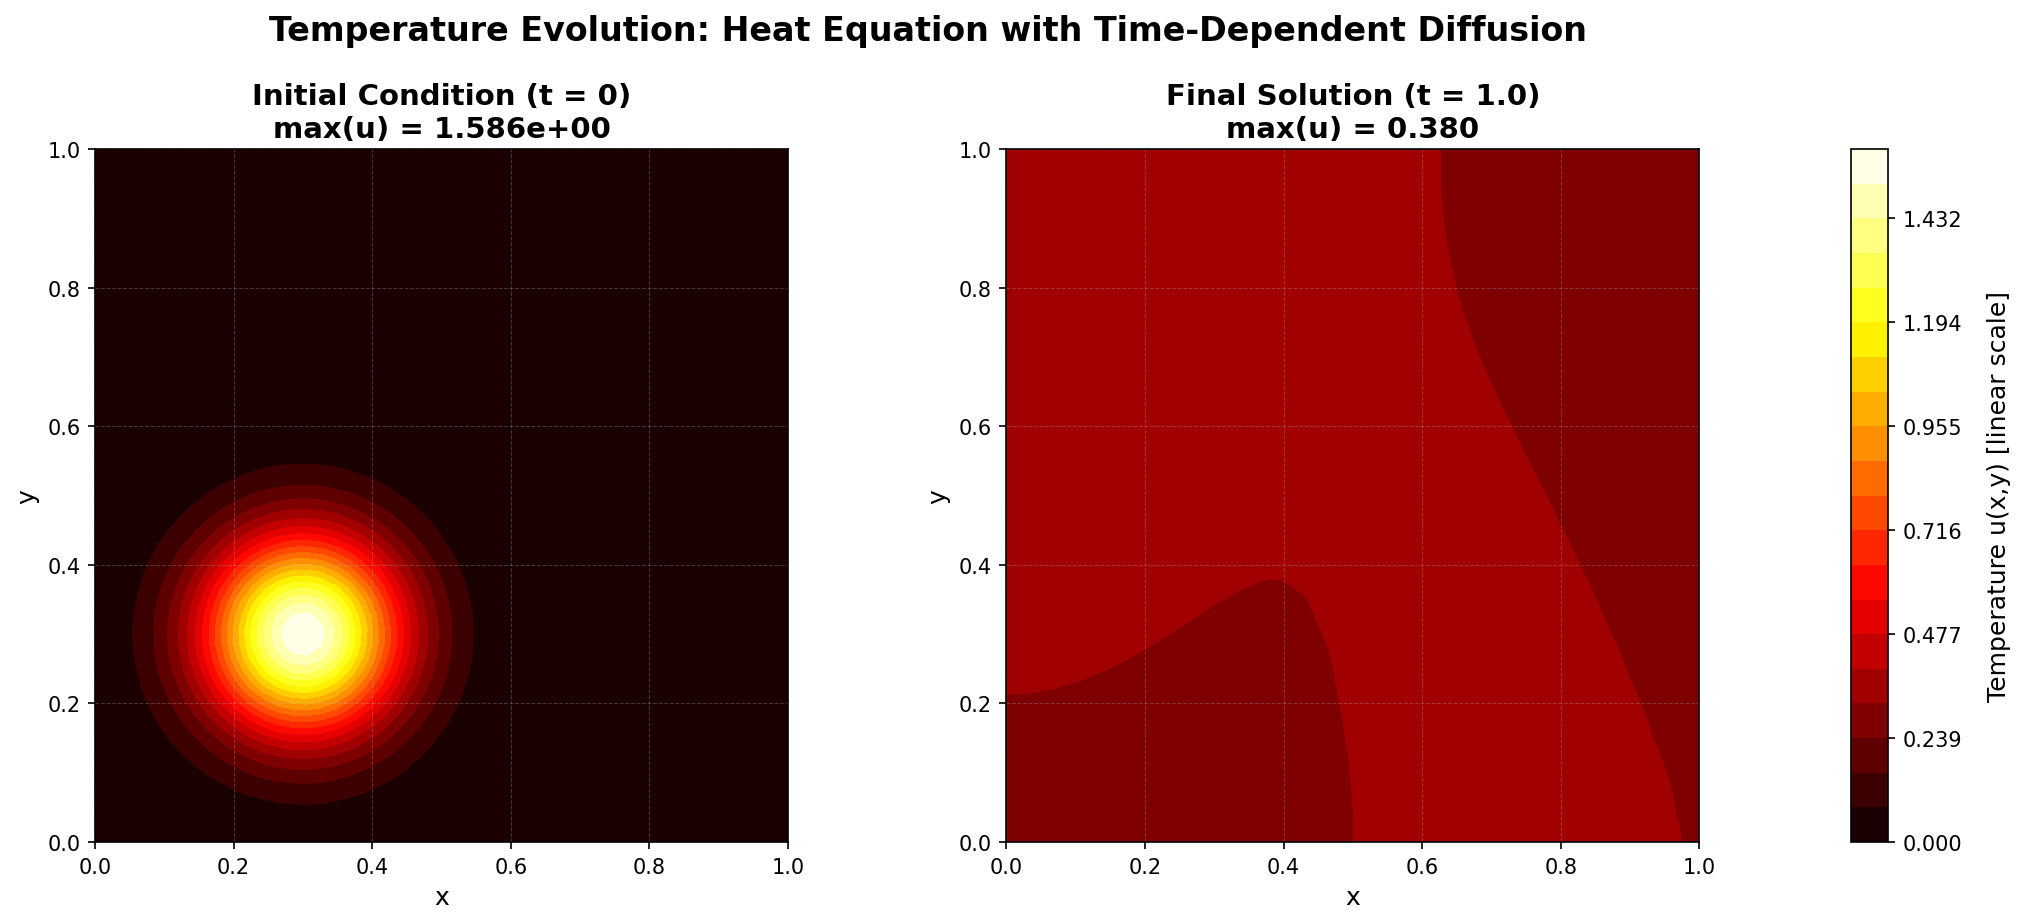

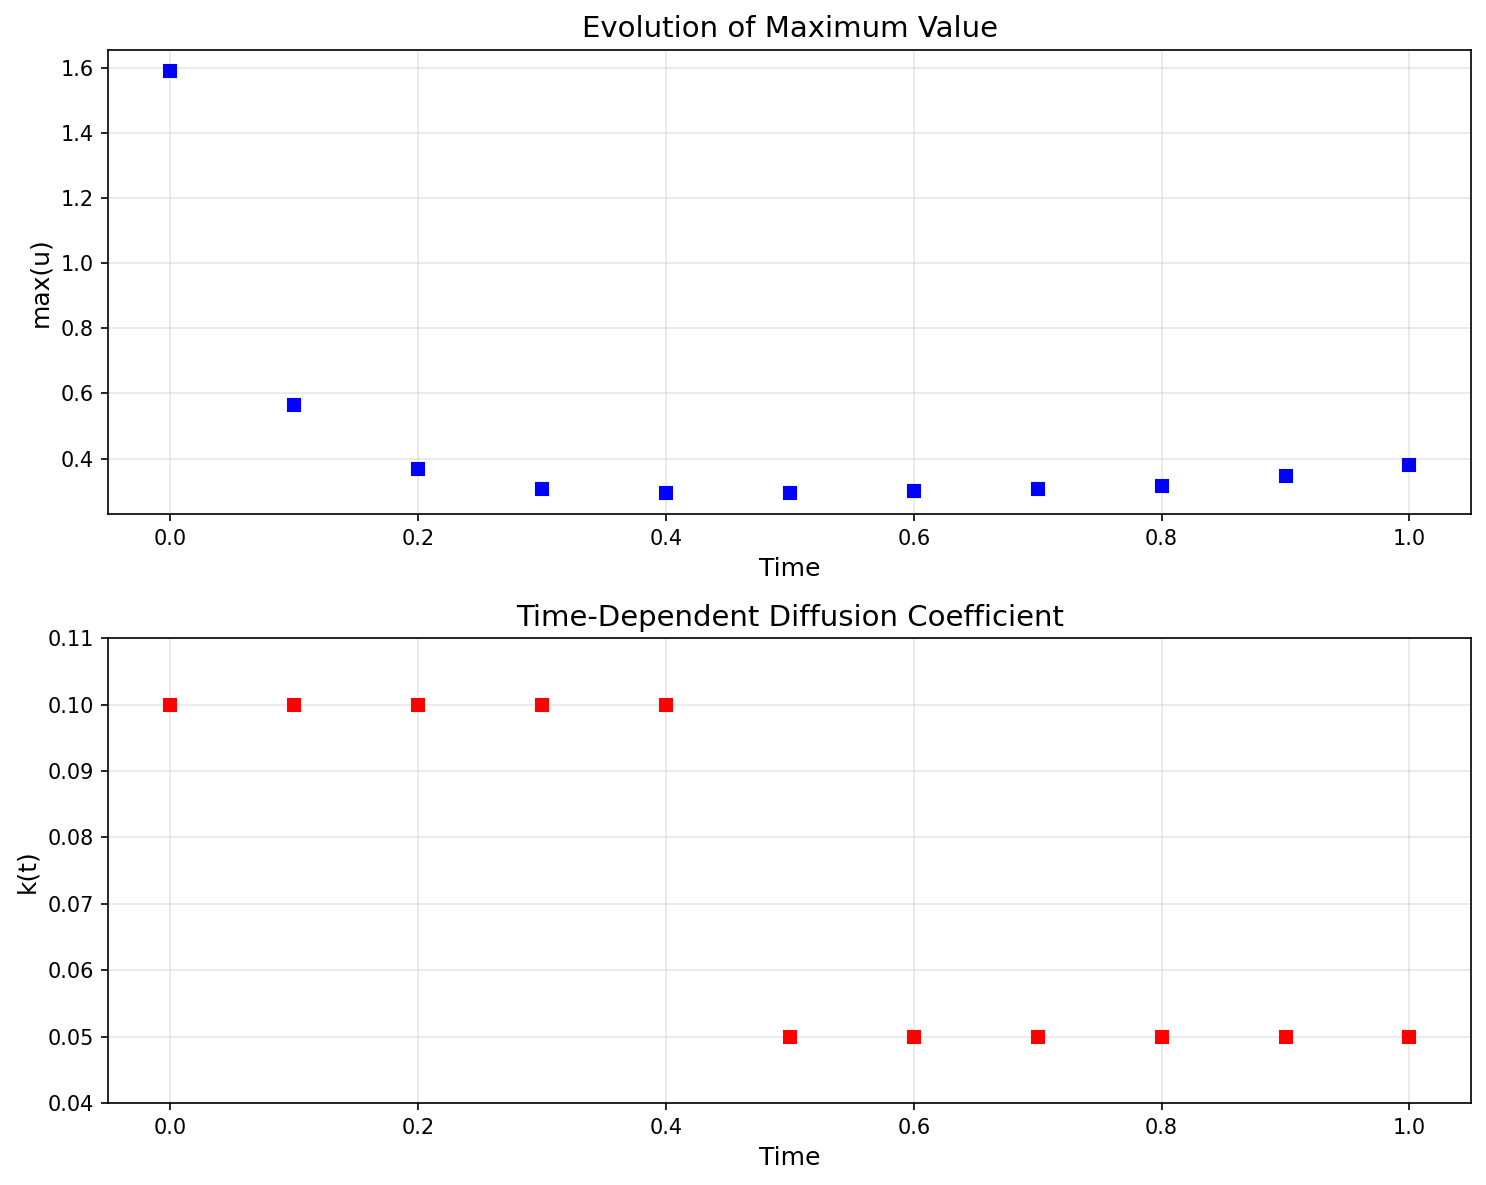

In [3]:
from IPython.display import Image, display, HTML

display(Image("initial_vs_final_solution_linear.png"))
display(HTML("<br>"))
display(Image("solution_evolution.png", width=500))

In [4]:
# ============================================================================
# COMPRESS PARAVIEW FILES FOR DOWNLOAD (Colab)
# ============================================================================
import os

# Check if running in Colab
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("\n" + "="*70)
    print("COMPRESSING FILES FOR DOWNLOAD")
    print("="*70)

    # Create archive of ParaView files
    print("\nCreating archive: paraview_files.zip")

    import zipfile
    with zipfile.ZipFile('paraview_files.zip', 'w', zipfile.ZIP_DEFLATED) as zipf:
        files_added = 0

        # Add time series files
        if os.path.exists('solution_time_series.bp'):
            print("\nAdding solution_time_series.bp/")
            for root, dirs, filenames in os.walk('solution_time_series.bp'):
                for filename in filenames:
                    filepath = os.path.join(root, filename)
                    arcname = os.path.relpath(filepath, '.')
                    zipf.write(filepath, arcname)
                    files_added += 1
            print(f"  ✓ Added {files_added} files")

        # Add final solution files
        files_before = files_added
        if os.path.exists('solution_final.bp'):
            print("\nAdding solution_final.bp/")
            for root, dirs, filenames in os.walk('solution_final.bp'):
                for filename in filenames:
                    filepath = os.path.join(root, filename)
                    arcname = os.path.relpath(filepath, '.')
                    zipf.write(filepath, arcname)
                    files_added += 1
            print(f"  ✓ Added {files_added - files_before} files")

    # Get file size
    file_size_bytes = os.path.getsize('paraview_files.zip')
    file_size_mb = file_size_bytes / (1024 * 1024)

    print(f"\n{'='*70}")
    print(f"Archive created: paraview_files.zip")
    print(f"  Total files: {files_added}")
    print(f"  Size: {file_size_mb:.2f} MB ({file_size_bytes:,} bytes)")
    print(f"{'='*70}")

    # Download the file
    print("\nDownloading paraview_files.zip...")
    files.download('paraview_files.zip')
    print("Download initiated! Check your browser's download folder.")

    print("\nAfter download:")
    print("  1. Extract paraview_files.zip")
    print("  2. Open ParaView")
    print("  3. File -> Open -> solution_time_series.bp")
    print("  4. Click Apply and use time controls to animate")

    print("\n" + "="*70)
else:
    print("\nNote: Not running in Google Colab.")
    print("ParaView files are in the current directory:")
    print("  - solution_time_series.bp/")
    print("  - solution_final.bp/")



COMPRESSING FILES FOR DOWNLOAD

Creating archive: paraview_files.zip

Adding solution_time_series.bp/
  ✓ Added 4 files

Adding solution_final.bp/
  ✓ Added 4 files

Archive created: paraview_files.zip
  Total files: 8
  Size: 0.45 MB (474,321 bytes)



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download initiated! Check your browser's download folder.

After download:
  1. Extract paraview_files.zip
  2. Open ParaView
  3. File -> Open -> solution_time_series.bp
  4. Click Apply and use time controls to animate

